# Mounting the Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Extraction of ZIP File

In [ ]:
import zipfile
import os

# Path to the ZIP file in Google Drive
zip_path = '/content/drive/MyDrive/Colab Notebooks/igc.zip'
extraction_dir = '/content/drive/MyDrive/ingame/ingame'

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print("Files extracted to:", extraction_dir)


Files extracted to: /content/drive/MyDrive/ingame/ingame


# Importing Libraries

In [ ]:
!sudo apt-get install tesseract-ocr
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 21 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (5,424 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debc

# Extraction of text

In [ ]:
import os
import cv2
from PIL import Image
import pytesseract

# Define a preprocessing function
def preprocess_image(image_path):
    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Resize to make the text more readable
    img = cv2.resize(img, None, fx=2, fy=2, interpolation=cv2.INTER_LINEAR)

    # Apply binarization (thresholding)
    img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    return img

# Directory containing extracted images
extraction_dir = '/content/drive/MyDrive/ingame/ingame/igc'

# Dictionary to store text for each image
extracted_texts = {}

# Process each image in the directory
for file_name in os.listdir(extraction_dir):
    if file_name.endswith(('.png', '.jpg', '.jpeg')):  # Check for image files
        image_path = os.path.join(extraction_dir, file_name)

        # Preprocess the image
        preprocessed_img = preprocess_image(image_path)

        # Extract text using Tesseract
        text = pytesseract.image_to_string(preprocessed_img)

        # Store the text in the dictionary
        extracted_texts[file_name] = text

# Save all extracted texts into a single file
output_file = '/content/drive/MyDrive/finalextracted_texts.txt'
with open(output_file, 'w') as f:
    for file_name, text in extracted_texts.items():
        f.write(f"\n{text}\n\n")

print("Text extraction complete. Results saved to:", output_file)


Text extraction complete. Results saved to: /content/drive/MyDrive/finalextracted_texts.txt


In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

# Open and read the text file
with open("/content/drive/MyDrive/finalextracted_texts.txt", 'r') as file:
    text_data = file.read()

# Create a pandas DataFrame with the text data
data = pd.DataFrame([text_data], columns=['text'])
data.head()

,text
0,\nDead_Shot » oak logs anyone?\nDead_Shot » do...


In [ ]:
import re

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Loading the data

In [ ]:
data=pd.read_excel('/content/drive/MyDrive/finalextracted_texts.txt')
data.head(10)

# Preprocessing

Punctuation

In [ ]:
#library that contains punctuation
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
#defining the function to remove punctuation
def remove_punctuation(text):
    punctuationfree="".join([i for i in text if i not in string.punctuation])
    return punctuationfree
#storing the puntuation free text
data['clean_msg']= data['Sentence'].apply(lambda x:remove_punctuation(x))
data.head()

,Sentence,clean_msg
0,go to spawn,go to spawn
1,give me cobblestone,give me cobblestone
2,pass me the water bucket,pass me the water bucket
3,I'll teach you the game,Ill teach you the game
4,<Submichthepro> follow you dumbass,Submichthepro follow you dumbass


Lower casing

In [ ]:
data['msg_lower']= data['clean_msg'].apply(lambda x: x.lower())
data.head()

,Sentence,clean_msg,msg_lower
0,go to spawn,go to spawn,go to spawn
1,give me cobblestone,give me cobblestone,give me cobblestone
2,pass me the water bucket,pass me the water bucket,pass me the water bucket
3,I'll teach you the game,Ill teach you the game,ill teach you the game
4,<Submichthepro> follow you dumbass,Submichthepro follow you dumbass,submichthepro follow you dumbass


Tokenization

In [ ]:
#defining function for tokenization
import re
def tokenization(text):
    tokens = re.split('W+',text)
    return tokens
#applying function to the column
data['msg_tokenied']= data['msg_lower'].apply(lambda x: tokenization(x))
data.head()

,Sentence,clean_msg,msg_lower,msg_tokenied
0,go to spawn,go to spawn,go to spawn,[go to spawn]
1,give me cobblestone,give me cobblestone,give me cobblestone,[give me cobblestone]
2,pass me the water bucket,pass me the water bucket,pass me the water bucket,[pass me the water bucket]
3,I'll teach you the game,Ill teach you the game,ill teach you the game,[ill teach you the game]
4,<Submichthepro> follow you dumbass,Submichthepro follow you dumbass,submichthepro follow you dumbass,[submichthepro follow you dumbass]


Stop word Removal

In [ ]:
#importing nlp library
import nltk
nltk.download('stopwords')

#Stop words present in the library
stopwords = nltk.corpus.stopwords.words('english')
stopwords[0:10]
['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

In [ ]:
#defining the function to remove stopwords from tokenized text
def remove_stopwords(text):
    output= [i for i in text if i not in stopwords]
    return output

In [ ]:
#applying the function
data['no_stopwords']= data['msg_tokenied'].apply(lambda x:remove_stopwords(x))

Stemming

In [ ]:
#importing the Stemming function from nltk library
from nltk.stem.porter import PorterStemmer
#defining the object for stemming
porter_stemmer = PorterStemmer()

In [ ]:
#defining a function for stemming
def stemming(Sentence):
  stem_text = [porter_stemmer.stem(word) for word in Sentence]
  return stem_text
data['msg_stemmed']=data['no_stopwords'].apply(lambda x: stemming(x))

In [ ]:
data.head()

,Sentence,clean_msg,msg_lower,msg_tokenied,no_stopwords
0,go to spawn,go to spawn,go to spawn,[go to spawn],[go to spawn]
1,give me cobblestone,give me cobblestone,give me cobblestone,[give me cobblestone],[give me cobblestone]
2,pass me the water bucket,pass me the water bucket,pass me the water bucket,[pass me the water bucket],[pass me the water bucket]
3,I'll teach you the game,Ill teach you the game,ill teach you the game,[ill teach you the game],[ill teach you the game]
4,<Submichthepro> follow you dumbass,Submichthepro follow you dumbass,submichthepro follow you dumbass,[submichthepro follow you dumbass],[submichthepro follow you dumbass]


In [ ]:
output_file = '/content/categorized_game_chats_nlp.csv'
data.to_csv(output_file, index=False)

In [ ]:
import pandas as pd
import re
import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Ensure necessary NLTK resources are downloaded
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

# Load dataset


# Display column names for clarity
print("Columns in dataset:", data.columns)

# Assume the chat column is named 'Chat'
chat_column = 'Sentence'

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Preprocess a single text entry."""
    # Lowercase the text
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to the chat column
data['Processed_Chat'] = data[chat_column].astype(str).apply(preprocess_text)

# Save preprocessed data for review
data.to_csv('/content/preprocessed_chat.csv', index=False)

print("Preprocessing complete! Processed data saved as 'preprocessed_chat.csv'.")


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Columns in dataset: Index(['Sentence'], dtype='object')
Preprocessing complete! Processed data saved as 'preprocessed_chat.csv'.


# Custom Lexicon

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Ensure necessary NLTK resources are downloaded
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

# Load dataset
df = pd.read_excel('/content/BEST CLASSIFCATION edited - Copy.xlsx')

# Display column names for clarity
print("Columns in dataset:", df.columns)

# Assume the chat column is named 'Chat'
chat_column = 'Sentence'

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Preprocess a single text entry."""
    # Lowercase the text
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to the chat column
df['Processed_Chat'] = df[chat_column].astype(str).apply(preprocess_text)

# Custom lexicon for classification
custom_lexicon = {
    'toxic': {
        'sh*t': 1, 'f*ck': 1, 'suck': 1, 'uninstall': 1, 'noob': 1,
        'bitch': 1, 'trash': 1, 'learn how to play': 1, 'useless': 1,
        'moron': 1, 'monkey': 1, 'chimpanzee': 1, 'sht': 1, 'fck': 1,'dumbass': 1, 'fk': 1, 'fking' : 1, 'ezzz' : 1, 'ez' : 1, 'loser' : 1, 'L' : 1, 'bad' : 1,
        'lost' : 1, 'feeding' : 1,'suck':1, 'bitch':1,  'ez':1, 'noobs':1, 'monkey':1, 'f**k':1, 'trash':1, 'loser':1, 'idiot':1, 'dumb':1,
    'failed':1, 'useless':1, 'garbage':1, 'pathetic':1, 'boosted':1, 'cheap':1, 'clueless':1, 'rage quit':1, 'keyboard warrior':1,
    'toxic':1, 'creep':1, 'rat':1, 'moron':1, 'dogsh*t':1, 'fk':1, 'sh*t':1, 'get good':1, 'you piece of':1, 'clap you':1,
    'you guys f**king suck':1, 'quit':1, 'braindead':1, 'ret*rded':1, 'you’re sh*t': 1, 'you f**king stupid':1
    },
    'neutral': {
        'gg': 1, 'nt': 1, 'mlg': 1, 'rotate': 1, 'hold site': 1,
        'cypher': 1, 'reyna': 1, 'clove': 1, 'sova': 1, 'wp': 1, 'mlg': 1,'ns':1,'lol': 1,'glhf': 1,'well played':1,'rotate':1, 'smoke':1, 'Cypher':1, 'Clove':1, 'Reyna':1, 'Jett':1, 'kills':1, 'shoot':1, 'flank':1, 'ult':1, 'plant':1, 'A':1, 'B':1, 'C':1,
    'gg':1, 'ns': 1, 'wp':1, 'nice shot':1, 'well played':1, 'good game':1, 'peek':1, 'dart':1, 'retake':1, 'bomb':1, 'garage':1, 'team':1,
    'site':1, 'backsite':1, 'main':1, 'spawn':1, 'heaven':1, 'flash':1, 'comms':1, 'push':1, 'cover':1, 'entry':1
    }

}

def classify_with_lexicon(text):
    """Classify text based on custom lexicon."""
    toxic_score = sum([weight for word, weight in custom_lexicon['toxic'].items() if word in text])
    neutral_score = sum([weight for word, weight in custom_lexicon['neutral'].items() if word in text])

    if toxic_score > neutral_score:
        return 'Toxic'
    elif neutral_score > toxic_score:
        return 'Neutral'
    else:
        return 'Neutral'  # Default to Neutral if scores are equal or absent

# Apply classification
df['Classification'] = df['Processed_Chat'].apply(classify_with_lexicon)

# Save the classified data
df.to_csv('/content/classified_chat_with_lexicon.csv', index=False)

print("Classification complete! Classified data saved as 'classified_chat_with_lexicon.csv'.")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Columns in dataset: Index(['Sentence'], dtype='object')
Classification complete! Classified data saved as 'classified_chat_with_lexicon.csv'.


#Data Visualization

#Bar Graph

<ipython-input-1-929d38d9c51d>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Category", palette="viridis")


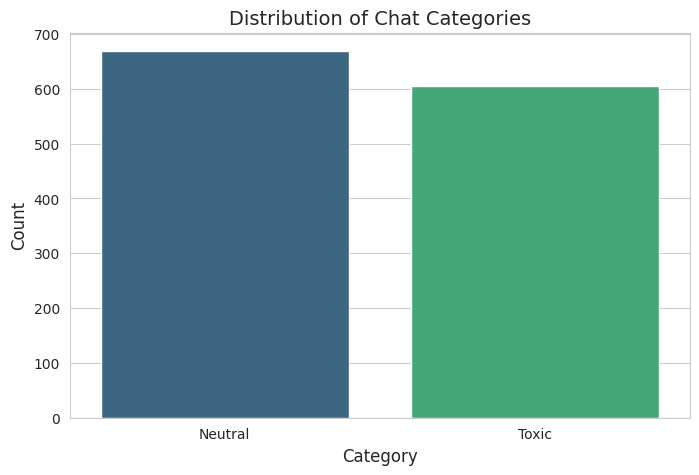

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
df = pd.read_excel("/content/BEST CLASSIFCATION edited.xlsx", sheet_name="BEST CLASSIFCATION")

# Set Seaborn style
sns.set_style("whitegrid")

# Count plot of categories
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Category", palette="viridis")
plt.title("Distribution of Chat Categories", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

#Pie Chart

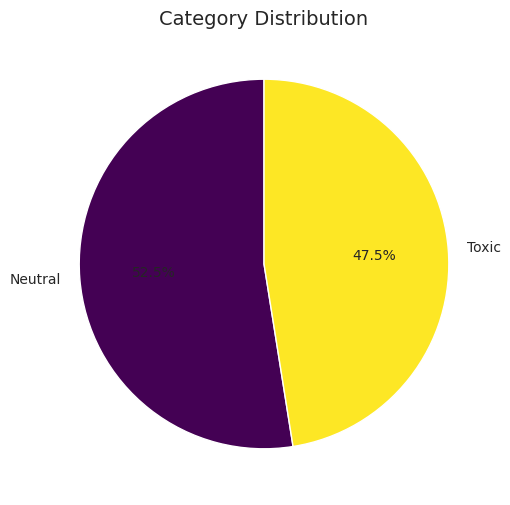

In [ ]:
plt.figure(figsize=(6, 6))
df["Category"].value_counts().plot.pie(autopct="%1.1f%%", cmap="viridis", startangle=90)
plt.title("Category Distribution", fontsize=14)
plt.ylabel("")
plt.show()

#Word Cloud

In [ ]:
from wordcloud import WordCloud

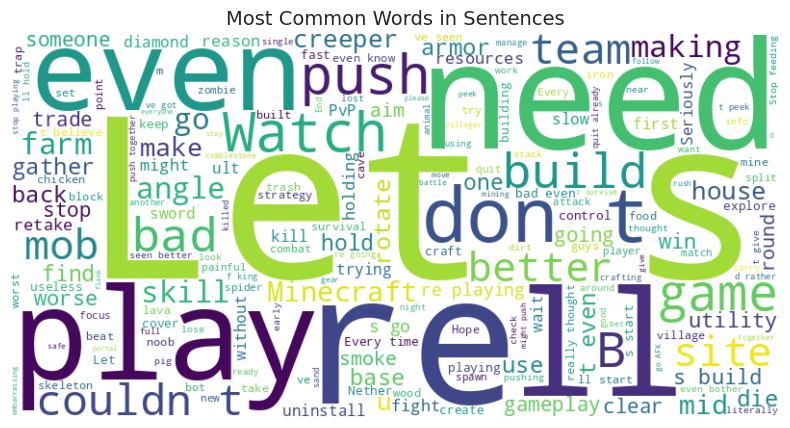

In [ ]:
text = " ".join(df["Sentence"].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Sentences", fontsize=14)
plt.show()


#Histogram

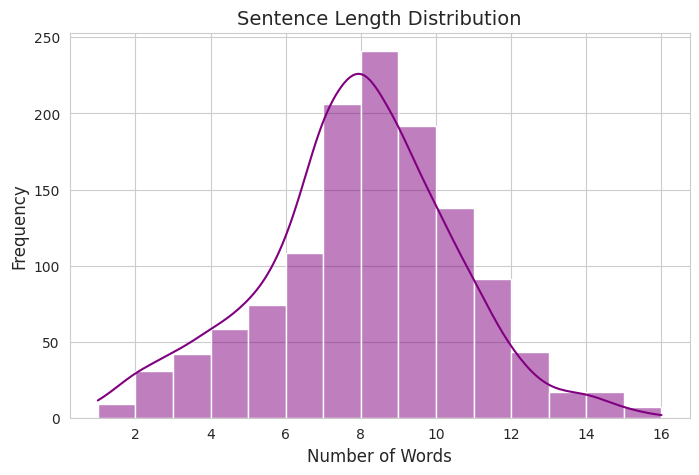

In [ ]:
sentence_lengths = df["Sentence"].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.histplot(sentence_lengths, bins=15, kde=True, color="purple")
plt.title("Sentence Length Distribution", fontsize=14)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

#Box Plot

<ipython-input-7-00c111a44949>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Category", y=sentence_lengths, palette="coolwarm")


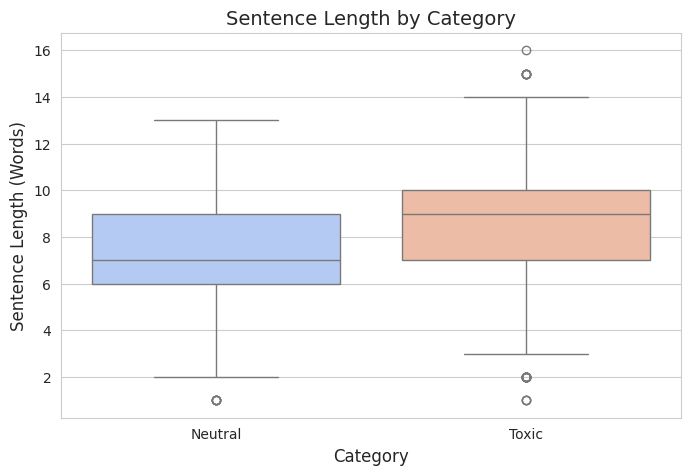

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Category", y=sentence_lengths, palette="coolwarm")
plt.title("Sentence Length by Category", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Sentence Length (Words)", fontsize=12)
plt.show()

# BERT

# 80-20

In [ ]:
import re
import torch
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import torch.nn as nn
import torch.optim as optim

# Ensure required NLTK resources are downloaded
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


df=pd.read_excel('/content/BEST CLASSIFCATION edited.xlsx')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Preprocess a single text entry."""
    # Lowercase the text
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to the chat column
df['Processed_Chat'] = df['Sentence'].astype(str).apply(preprocess_text)

# Dataset class
class ChatDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Create a mapping from label strings to numerical values
        self.label_mapping = {'Neutral': 0, 'Toxic': 1}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Convert the label string to its corresponding numerical value
        label = self.label_mapping[label]

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Prepare data
train_texts, val_texts, train_labels, val_labels = train_test_split(df['Processed_Chat'], df['Category'], test_size=0.2,random_state=2)
train_dataset = ChatDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = ChatDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Define Model
class ToxicityClassifier(nn.Module):
    def __init__(self, bert_model="bert-base-uncased", num_classes=2):
        super(ToxicityClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        return self.fc(x)

# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ToxicityClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

# Training Loop
def train_model(model, train_loader, val_loader, epochs=6):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

# Train Model
train_model(model, train_loader, val_loader)

# Save Model
torch.save(model.state_dict(), "bert_toxicity_classifier.pth")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1, Loss: 0.5385214178822935
Epoch 2, Loss: 0.32462939037941396
Epoch 3, Loss: 0.21327619726071134
Epoch 4, Loss: 0.16196143010165542
Epoch 5, Loss: 0.12111629382707179
Epoch 6, Loss: 0.11431958083994687


In [ ]:
def test_model(model, val_loader):
    model.eval()
    total_loss = 0
    total_accuracy = 0  # Store cumulative accuracy

    for batch in val_loader:
        input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Calculate accuracy
        # Assuming your model outputs logits, you need to apply softmax to get probabilities
        _, predicted = torch.max(outputs, 1)
        total_accuracy += (predicted == labels).sum().item() / len(labels)

    print("Loss:", total_loss / len(val_loader))
    print("Accuracy:", (total_accuracy / len(val_loader)) * 100, "%")  # Average accuracy and convert to percentage


In [ ]:
test_model(model,val_loader)


Loss: 0.26688048150390387
Accuracy: 89.453125 %


#Forecasting

In [ ]:
def predict_text(model, tokenizer, texts, device): # Changed text to texts to reflect list input
    model.eval()
    predictions = [] #initialize a list to store the predictions
    for text in texts: # iterate through each text
        encoding = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            output = model(input_ids, attention_mask)
            prediction = torch.argmax(output, dim=1).item()
        predictions.append("Toxic" if prediction == 1 else "Neutral") #append each individual prediction to the predictions list

    return predictions # return the list of predictions

# Load Model for Inference
model.load_state_dict(torch.load("bert_toxicity_classifier.pth", map_location=device))
model.to(device)

#  Prediction
to_classify = ["55 on brim",
                    "Cover me",
                    "Creeper over there",
                    "Shoot him he's low",
                    "Skeletons coming",
                    "Dumb fck",
                    "Brainless coward",
                    "GG boys",
               "Wp",
               "Too ezzz",
               "Can you pass me the cobblestone",
               "there's mlg clutch",
               "pass me the enchantment table",
               "Braindead person","Dogsh*t","Brainless coward","Can you just learn how to play stupid?","You are a bitch","Yo bro wanna team up?","GG guys wp","ns my G","nt bro","W strat"]
predictions = predict_text(model, tokenizer, to_classify, device) #changed prediction to predictions
for sentence, prediction in zip(to_classify, predictions): # iterate through both lists
    print(f"Sentence: {sentence} -> Classification: {prediction}")

<ipython-input-31-93dbddd2cec9>:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("bert_toxicity_classifier.pth", map_location=device))


Sentence: 55 on brim -> Classification: Neutral
Sentence: Cover me -> Classification: Neutral
Sentence: Creeper over there -> Classification: Neutral
Sentence: Shoot him he's low -> Classification: Neutral
Sentence: Skeletons coming -> Classification: Neutral
Sentence: Dumb fck -> Classification: Toxic
Sentence: Brainless coward -> Classification: Toxic
Sentence: GG boys -> Classification: Neutral
Sentence: Wp -> Classification: Neutral
Sentence: Too ezzz -> Classification: Toxic
Sentence: Can you pass me the cobblestone -> Classification: Neutral
Sentence: there's mlg clutch -> Classification: Neutral
Sentence: pass me the enchantment table -> Classification: Neutral
Sentence: Braindead person -> Classification: Toxic
Sentence: Dogsh*t -> Classification: Toxic
Sentence: Brainless coward -> Classification: Toxic
Sentence: Can you just learn how to play stupid? -> Classification: Toxic
Sentence: You are a bitch -> Classification: Toxic
Sentence: Yo bro wanna team up? -> Classification: 

# 60-40

In [ ]:
import re
import torch
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import torch.nn as nn
import torch.optim as optim

# Ensure required NLTK resources are downloaded
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


df=pd.read_excel('/content/BEST CLASSIFCATION edited.xlsx')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Preprocess a single text entry."""
    # Lowercase the text
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to the chat column
df['Processed_Chat'] = df['Sentence'].astype(str).apply(preprocess_text)

# Dataset class
class ChatDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Create a mapping from label strings to numerical values
        self.label_mapping = {'Neutral': 0, 'Toxic': 1}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Convert the label string to its corresponding numerical value
        label = self.label_mapping[label]

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Prepare data
train_texts, val_texts, train_labels, val_labels = train_test_split(df['Processed_Chat'], df['Category'], test_size=0.4,random_state=5)
train_dataset = ChatDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = ChatDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Define Model
class ToxicityClassifier(nn.Module):
    def __init__(self, bert_model="bert-base-uncased", num_classes=2):
        super(ToxicityClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        return self.fc(x)

# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ToxicityClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.00002)

# Training Loop
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

# Train Model
train_model(model, train_loader, val_loader)

# Save Model
torch.save(model.state_dict(), "bert_toxicity_classifier.pth")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch 1, Loss: 0.5346785871855294
Epoch 2, Loss: 0.3267929737145702
Epoch 3, Loss: 0.23447943785383055
Epoch 4, Loss: 0.17007353447843343
Epoch 5, Loss: 0.13772827413292058


In [ ]:
def test_model(model, val_loader):
    model.eval()
    total_loss = 0
    total_accuracy = 0  # Store cumulative accuracy

    for batch in val_loader:
        input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Calculate accuracy
        # Assuming your model outputs logits, you need to apply softmax to get probabilities
        _, predicted = torch.max(outputs, 1)
        total_accuracy += (predicted == labels).sum().item() / len(labels)

    print("Loss:", total_loss / len(val_loader))
    print("Accuracy:", (total_accuracy / len(val_loader)) * 100, "%")  # Average accuracy and convert to percentage


In [ ]:
test_model(model, val_loader)

Loss: 0.3235849612028687
Accuracy: 87.5 %


In [ ]:
def predict_text(model, tokenizer, text, device):
    model.eval()
    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        output = model(input_ids, attention_mask)
        prediction = torch.argmax(output, dim=1).item()

    return "Toxic" if prediction == 1 else "Neutral"

# Load Model for Inference
model.load_state_dict(torch.load("bert_toxicity_classifier.pth", map_location=device))
model.to(device)

# Example Prediction
example_sentence = " Go and plant the bomb"
prediction = predict_text(model, tokenizer, example_sentence, device)
print(f"Sentence: {example_sentence} -> Classification: {prediction}")


<ipython-input-40-963dd9799a73>:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("bert_toxicity_classifier.pth", map_location=device))


Sentence:  Go and plant the bomb -> Classification: Neutral


# LSTM

In [ ]:
import re
import torch
import nltk
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import torch.nn as nn
import torch.optim as optim


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


df=pd.read_excel('/content/BEST CLASSIFCATION edited.xlsx')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Preprocess a single text entry."""
    # Lowercase the text
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to the chat column
df['Processed_Chat'] = df['Sentence'].astype(str).apply(preprocess_text)
# Dataset class
class ChatDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Create a mapping from label strings to numerical values
        self.label_mapping = {'Neutral': 0, 'Toxic': 1}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Convert the label string to its corresponding numerical value
        label = self.label_mapping[label]

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Tokenizer (still using BertTokenizer to tokenize input text for LSTM)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Prepare data
train_texts, val_texts, train_labels, val_labels = train_test_split(df['Processed_Chat'], df['Category'], test_size=0.2)
train_dataset = ChatDataset(train_texts.tolist(), train_labels.tolist(), tokenizer)
val_dataset = ChatDataset(val_texts.tolist(), val_labels.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Define Model (LSTM-based)
class ToxicityClassifierLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, num_classes=2, max_len=128):
        super(ToxicityClassifierLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # Multiply by 2 because of bidirectional LSTM
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask=None):
        embedded = self.embedding(input_ids)  # Embedding the input tokens
        lstm_out, _ = self.lstm(embedded)  # LSTM forward pass
        # Use the last hidden state of LSTM for classification
        lstm_out = lstm_out[:, -1, :]  # Get the output of the last timestep
        x = self.dropout(lstm_out)
        return self.fc(x)

# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define vocab_size based on the tokenizer
vocab_size = len(tokenizer.vocab)

model = ToxicityClassifierLSTM(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

# Training Loop
def train_model(model, train_loader, val_loader, epochs=150):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

# Train Model
train_model(model, train_loader, val_loader)

# Save Model
torch.save(model.state_dict(), "lstm_toxicity_classifier.pth")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Epoch 1, Loss: 0.7061494151130319
Epoch 2, Loss: 0.69343142490834
Epoch 3, Loss: 0.6916824579238892
Epoch 4, Loss: 0.6933435369282961
Epoch 5, Loss: 0.6914181113243103
Epoch 6, Loss: 0.6918015722185373
Epoch 7, Loss: 0.6912993425503373
Epoch 8, Loss: 0.6941411290317774
Epoch 9, Loss: 0.6921432018280029
Epoch 10, Loss: 0.6919293915852904
Epoch 11, Loss: 0.6923956358805299
Epoch 12, Loss: 0.6917797792702913
Epoch 13, Loss: 0.691086933016777
Epoch 14, Loss: 0.6915747979655862
Epoch 15, Loss: 0.6935133570805192
Epoch 16, Loss: 0.6915747439488769
Epoch 17, Loss: 0.6913737673312426
Epoch 18, Loss: 0.6904711797833443
Epoch 19, Loss: 0.6940567689016461
Epoch 20, Loss: 0.6935457196086645
Epoch 21, Loss: 0.6919223833829165
Epoch 22, Loss: 0.6952238911762834
Epoch 23, Loss: 0.6895790994167328
Epoch 24, Loss: 0.6909599816426635
Epoch 25, Loss: 0.6914439592510462
Epoch 26, Loss: 0.6935370620340109
Epoch 27, Loss: 0.693853116594255
Epoch 28, Loss: 0.6941422875970602
Epoch 29, Loss: 0.690831161104142

In [ ]:
def test_model(model, val_loader):
    model.eval()
    total_loss = 0
    total_accuracy = 0  # Store cumulative accuracy

    with torch.no_grad():  # Disable gradient calculation during evaluation
        for batch in val_loader:
            input_ids, attention_mask, labels = batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['label'].to(device)
           # optimizer.zero_grad()  # Remove this line as it's not needed during evaluation
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            #loss.backward()   # Remove this line, gradients are not needed in testing
            #optimizer.step() # Remove this line, weights should not be updated during testing
            total_loss += loss.item()

            # Calculate accuracy
            # Assuming your model outputs logits, you need to apply softmax to get probabilities
            _, predicted = torch.max(outputs, 1)
            total_accuracy += (predicted == labels).sum().item() / len(labels)

    print("Loss:", total_loss / len(val_loader))
    print("Accuracy:", (total_accuracy / len(val_loader)) * 100, "%")  # Average accuracy and convert to percentage

In [ ]:
test_model(model, val_loader)

Loss: 0.6952146738767624
Accuracy: 50.390625 %


# GRU (Gated Recurrent Unit)

In [ ]:
class ChatDataset(Dataset):
    def __init__(self, texts, labels, tokenizer=None, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.word_to_index = self.build_vocab(texts)
        # Create a mapping from label strings to numerical values
        self.label_mapping = {'Neutral': 0, 'Toxic': 1}

    def build_vocab(self, texts):
        """Build vocabulary from texts."""
        word_to_index = {"<PAD>": 0}
        for text in texts:
            for word in text.split():
                if word not in word_to_index:
                    word_to_index[word] = len(word_to_index)
        return word_to_index

    def text_to_sequence(self, text):
        """Convert text to sequence of indices."""
        return [self.word_to_index.get(word, 0) for word in text.split()]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Convert text to sequence of indices
        sequence = self.text_to_sequence(text)

        # Pad the sequence to ensure uniform length
        padded_sequence = sequence[:self.max_len] + [0] * (self.max_len - len(sequence))

        # Convert the label string to its corresponding numerical value
        label = self.label_mapping.get(label, 0) # Get numerical label, default to 0 if not found

        return {
            'input_ids': torch.tensor(padded_sequence, dtype=torch.long),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Prepare data
train_texts, val_texts, train_labels, val_labels = train_test_split(df['Processed_Chat'], df['Category'], test_size=0.4, random_state=5)
train_dataset = ChatDataset(train_texts.tolist(), train_labels.tolist())
val_dataset = ChatDataset(val_texts.tolist(), val_labels.tolist())

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# Define Model
class ToxicityClassifierGRU(nn.Module):
    def __init__(self, vocab_size, embed_size=100, hidden_size=128, num_classes=2, max_len=128):
        super(ToxicityClassifierGRU, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        gru_out, _ = self.gru(x)
        gru_out = gru_out[:, -1, :]  # Take the last hidden state
        x = self.dropout(gru_out)
        return self.fc(x)

# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = len(train_dataset.word_to_index)
model = ToxicityClassifierGRU(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

# Training Loop
def train_model(model, train_loader, val_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

    # Validation after training
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids, labels = batch['input_ids'].to(device), batch['label'].to(device)
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Validation Accuracy: {100 * correct / total}%")

# Train Model
train_model(model, train_loader, val_loader)

# Save Model
torch.save(model.state_dict(), "gru_toxicity_classifier.pth")


Epoch 1, Loss: 0.6954986297023233
Epoch 2, Loss: 0.6928072406359368
Epoch 3, Loss: 0.6932981135957528
Epoch 4, Loss: 0.6924255655698127
Epoch 5, Loss: 0.6933068324133987
Validation Accuracy: 52.25933202357564%


#Valuation

In [ ]:
import zipfile
import os

# Path to the ZIP file in Google Drive
zip_path = '/content/drive/MyDrive/Colab Notebooks/Valuation.zip'
extraction_dir = '/content/drive/MyDrive/Valuation'

# Extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print("Files extracted to:", extraction_dir)


Files extracted to: /content/drive/MyDrive/Valuation


In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import cv2
import pytesseract
import easyocr
import re
import torch
from PIL import Image
from transformers import BertTokenizer, BertModel
import torch.nn as nn

# Define Model
class ToxicityClassifier(nn.Module):
    def __init__(self, bert_model="bert-base-uncased", num_classes=2):
        super(ToxicityClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(bert_model)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        x = self.dropout(pooled_output)
        return self.fc(x)

# Load your trained model and tokenizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the tokenizer using the correct pre-trained model name
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Instantiate the model *before* loading the state dictionary
model = ToxicityClassifier()

model.load_state_dict(torch.load("bert_toxicity_classifier.pth", map_location=device))
model.to(device)


# Initialize EasyOCR reader
reader = easyocr.Reader(['en'])


import cv2
import pytesseract

def preprocess_and_ocr(image_path):
    """Preprocess image and apply OCR"""
    image = cv2.imread(image_path)

    if image is None:
        print(f"Error: Could not read the image at path: {image_path}. Please check the file path and ensure the file exists and is a valid image.")
        return ""

    # Resize for better OCR detection
    image = cv2.resize(image, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply sharpening
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,1))
    sharpened = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)

    # Apply OCR
    text = pytesseract.image_to_string(sharpened, config="--psm 6")
    return text.strip()

# Run OCR
extracted_text = preprocess_and_ocr("Screenshot 2024-12-14 005614.png")
print(extracted_text)



def extract_text_from_image(image_path):
    """Extracts text using improved OCR processing."""
    preprocessed_image = preprocess_image(image_path)
    text_tesseract = pytesseract.image_to_string(preprocessed_image, config="--psm 6")
    text_easyocr = ' '.join(reader.readtext(image_path, detail=0))  # EasyOCR output

    # Use EasyOCR if it gives better results
    return text_easyocr if len(text_easyocr) > len(text_tesseract) else text_tesseract

def clean_text(text):
    """Removes unwanted characters and fixes common OCR mistakes."""
    text = re.sub(r'[^A-Za-z0-9\s.,!?]', '', text)  # Keep only useful characters
    return text.strip()

def predict_text(model, tokenizer, texts, device):
    """Classifies extracted text as Toxic or Neutral."""
    model.eval()
    predictions = []
    for text in texts:
        encoding = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        with torch.no_grad():
            output = model(input_ids, attention_mask)
            prediction = torch.argmax(output, dim=1).item()
        predictions.append("Toxic" if prediction == 1 else "Neutral")

    return predictions

# Process New Images
image_paths = ["/content/image1.png", "/content/Screenshot 2024-12-09 195040.png", "/content/image5.png", "/content/Screenshot 2024-12-10 160506.png","/content/Screenshot 2024-12-27 184019.png"]  # Replace with actual file paths
extracted_texts = [clean_text(extract_text_from_image(img)) for img in image_paths]

# Remove empty text results
extracted_texts = [text for text in extracted_texts if text]

# Classify Extracted Text
predictions = predict_text(model, tokenizer, extracted_texts, device)

# Print Results
for text, prediction in zip(extracted_texts, predictions):
    print(f"Extracted Text: {text} -> Classification: {prediction}")

<ipython-input-9-8622646e5eb0>:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("bert_toxicity_classifier.pth", map_location=device))


Error: Could not read the image at path: Screenshot 2024-12-14 005614.png. Please check the file path and ensure the file exists and is a valid image.

Extracted Text: outside A main -> Classification: Neutral
Extracted Text: ocel
im actually dogsht -> Classification: Toxic
Extracted Text: Oie Jett Sova A -> Classification: Neutral
Extracted Text: horrible team -> Classification: Toxic
Extracted Text: ggWpP -> Classification: Neutral
